#### Week 4 Homework 

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(2026)

**1. (15 pts) Using the data provided. Generate a line chart such that:**
- **X axis must have:**
   - **A maximum of 10 major tickmarks.**
   - **Each major ticklabels should have the following string format '%.0f'.**
   - **Minor tick marks will be set at 0.5 intervals.**
   - **No minor labels**
- **Y axis must have:**
  - **A major tick mark at each 0.5 interval.**
  - **A custom function formatter that shows two decimals and appends a unit string '{value:.2f} units'.**
  - **An automatic minor locator between major ticks.**

```{note}
Whatever function you use with `FuncFormatter()` make sure that it receives at least two parameters: 
- one for the label you want to format
- one of the position which you can ignore for the purposes of your formatting.
```

**DATA:**

In [2]:
# Data
x = np.linspace(0, 10, 500)
y = np.sin(x) * (1.0 + 0.3 * np.cos(3 * x))

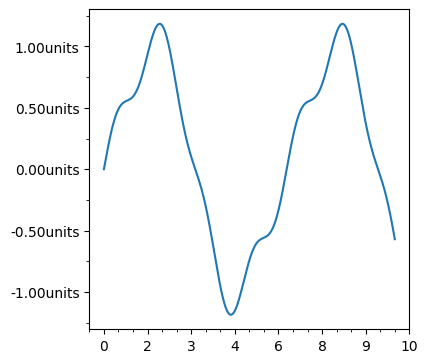

In [3]:

# YOUR CODE HERE
import matplotlib.ticker as ticker
def custom_format(x, pos):
    return f'{x:.2f}units'#used example from class; is 'pos' for the label?

fig = plt.figure(figsize=(4, 4))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
#x axis tick settings
ax.xaxis.set_major_locator(ticker.MaxNLocator(9))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
#y axis tick settings
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(custom_format))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=2))

ax.plot(x,y)
plt.show()

**2. (10 pts) You're comparing pottery assemblages from site HBMH (Horvat Be'er Milka Hasmonean) to regional averages. The pottery is classified into four functional categories: cooking vessels, storage jars, ritual vessels (least common), and other ceramics. Recreate the grouped bar chart shown in the output image.**

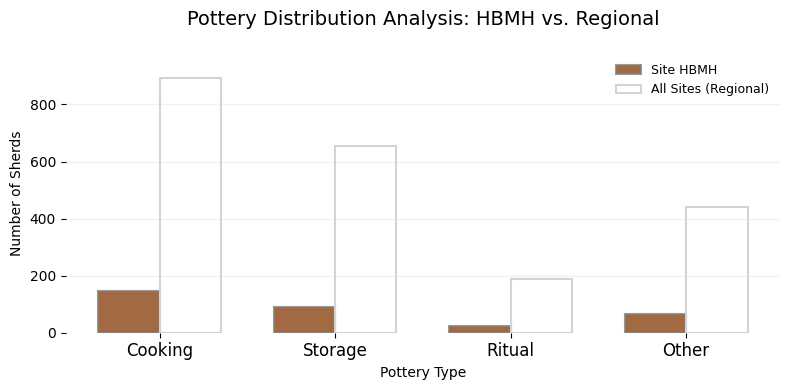

**Requirements:**

- **Figure size: (8, 4)**
- **Grouped bars: bar_width = 0.35**
- **HBMH bars: color='#8B4513', alpha=0.8, edgecolor='gray', linewidth=1.5**
- **Title: 'Pottery Distribution Analysis: HBMH vs. Regional' (fontsize=14)**

*Hint*. To create side-by-side grouped bars, offset the x-positions: use `x_pos - bar_width/2` for HBMH bars and `x_pos + bar_width/2` for All Sites bars.

**DATA:**

In [4]:
# Data
categories = ['Cooking', 'Storage', 'Ritual', 'Other']
hbmh_counts = [145, 89, 23, 67]  
all_sites_counts = [892, 654, 187, 441]  # Regional averages - larger quantities

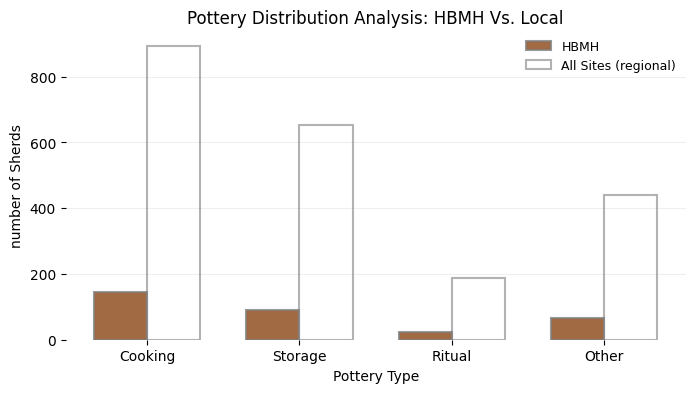

In [5]:
# YOUR CODE HERE
import numpy as np
import matplotlib.pyplot as plt

# Data
group1 = [20, 34, 30, 35]
group2 = [25, 32, 34, 20]

x = np.arange(len(categories))  # label locations
width = 0.35                     # width of the bars

fig, ax = plt.subplots(figsize = (8,4))

ax.bar(x - width/2, hbmh_counts, width, label='HBMH', 
       color='#8B4513', alpha=0.8, edgecolor='gray', linewidth=1.5)
ax.bar(x + width/2, all_sites_counts, width, label='All Sites (regional)', 
       fill = False, edgecolor='gray', linewidth=1.5, alpha = 0.6)

# Labels & formatting
ax.set_ylabel('number of Sherds')
ax.set_title('Pottery Distribution Analysis: HBMH Vs. Local')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_xlabel('Pottery Type')
ax.legend(frameon = False
        , bbox_to_anchor=(0.725,1.01), loc='upper left'
         ,fontsize = 9)

#getting rid of spines
ax.spines['right'].set_visible(False)# right 
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)# right 
ax.spines['left'].set_visible(False)# top

#horizontal grid
ax.yaxis.grid(True, which='major', alpha=0.2)
ax.set_axisbelow(True)  # draw grid lines behind bars


plt.show()


**3. (25 pts) You're creating a visualization showing the vertical distribution of three types of archaeological materials (charcoal, bone fragments, and ceramic sherds) found at different depths in an excavation. The depth axis should appear separately between the charcoal plot and the other two material plots to emphasize the grouping. Recreate the plot shown in the output image.**

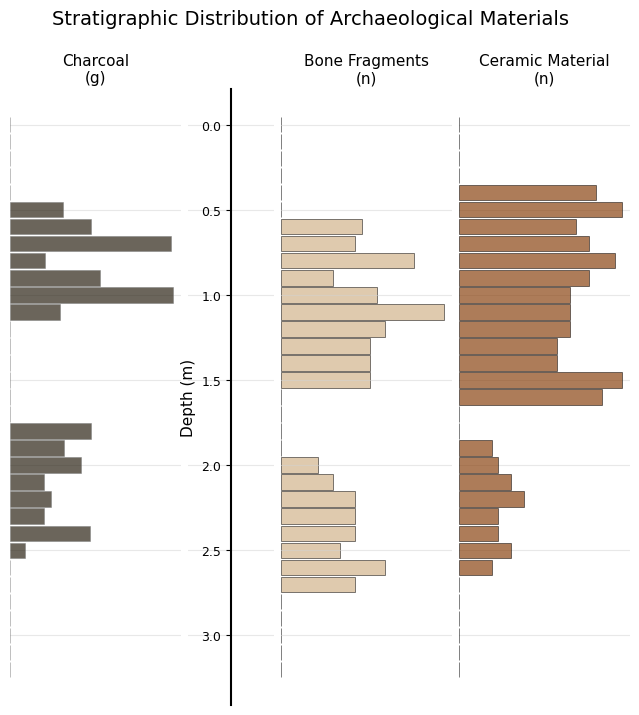

**Requirements:**
- **Figure size: (8, 8)**
- **Four subplots using GridSpec with width_ratios=[1, 0.5, 1, 1], wspace=0.05**
- **Horizontal bar charts (height=0.09)**
- **Colors: Charcoal='#2C2416', Bone='#D2B48C', Ceramic='#8B4513'**
- **All bars: alpha=0.7, edge colors visible**
- **Depth axis inverted (surface at top)**
- **No spines visible on data plots**
- **Y-axis grid on all plots (color='lightgray', alpha=0.5, behind bars)**
- **No x-axis ticks or labels on any plot**
- **Titles with units in parentheses**

*Hint 1 - GridSpec Layout:*
You need 4 subplots where the second one (gs[1]) is dedicated solely to the depth axis with no data plotted. All other plots will share their y-axis with this subplot.

*Hint 2 - Grid Without Visible Ticks:*
To show grid lines without visible tick marks on the data plots, use `ax.tick_params(axis='y', length=0, labelleft=False)` instead of `ax.set_yticks([])`. The latter removes tick positions entirely, which also removes grid lines. Adjust zorder so that the gridlines appear **behind** the bars.

*Hint 3 - Depth Axis Positioning:*
For ax2 (depth axis), position the left spine at the center using `.set_position(('axes', 0.5))` and remove the other three spines. This creates a vertical axis line in the middle of that subplot space, separating the charcoal plot from the bone/ceramic plots.

**DATA:**

In [6]:
# Data
depth = np.arange(0, 3.21, 0.1)  # 0, 0.1, 0.2, ..., 3.2 meters

# Generate CHARCOAL data (grams) - with gaps (some zeros)
charcoal = np.zeros(len(depth))
charcoal_indices_1 = (depth >= 0.5) & (depth <= 1.2)
charcoal_indices_2 = (depth >= 1.8) & (depth <= 2.5)
charcoal[charcoal_indices_1] = np.random.uniform(2, 15, charcoal_indices_1.sum())
charcoal[charcoal_indices_2] = np.random.uniform(1, 8, charcoal_indices_2.sum())

# Generate BONE FRAGMENTS data (counts) - with gaps
bone = np.zeros(len(depth))
bone_indices_1 = (depth >= 0.6) & (depth <= 1.5)
bone_indices_2 = (depth >= 2.0) & (depth <= 2.8)
bone[bone_indices_1] = np.random.poisson(12, bone_indices_1.sum())
bone[bone_indices_2] = np.random.poisson(8, bone_indices_2.sum())

# Generate CERAMIC MATERIAL data (counts) - with gaps
ceramic = np.zeros(len(depth))
ceramic_indices_1 = (depth >= 0.4) & (depth <= 1.6)
ceramic_indices_2 = (depth >= 1.9) & (depth <= 2.6)
ceramic[ceramic_indices_1] = np.random.poisson(20, ceramic_indices_1.sum())
ceramic[ceramic_indices_2] = np.random.poisson(10, ceramic_indices_2.sum())

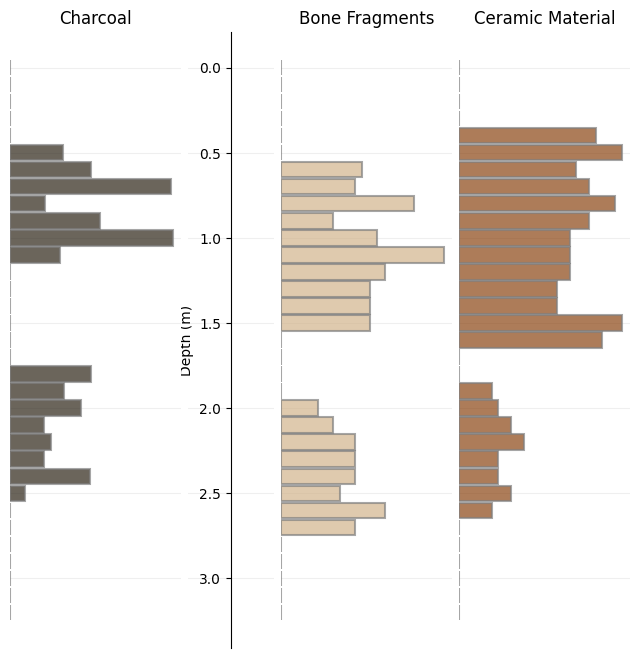

In [7]:
# YOUR CODE HERE
import numpy as np
import matplotlib.ticker as ticker
fig = plt.figure(figsize = (8, 8))
gs = fig.add_gridspec(1, 4, width_ratios = [1, 0.5, 1, 1], wspace = 0.05)

# create figures, Use sharey so that the reference axis matches
ax2 = fig.add_subplot(gs[0,1]) #created first so sharey works for all

ax1 = fig.add_subplot(gs[0,0], sharey=ax2)
ax3 = fig.add_subplot(gs[0,2], sharey=ax2)
ax4 = fig.add_subplot(gs[0,3], sharey=ax2)

#arranging ticks
max_depth = np.max(depth)
ticks = -np.arange(0, max_depth + 0.5, 0.5)

ax2.yaxis.set_major_locator(ticker.FixedLocator(ticks))
ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: f"{abs(y):.1f}")
)

#ax1.yaxis.set_major_locator(ticker.FixedLocator(-depth))#setting ticks for reference axis
axes = [ax1, ax2, ax3, ax4]#for automation #not needed, list constructed later

#bar charts
ax1.set_title('Charcoal')
ax1.barh(y = (depth*(-1)),
        width = charcoal,
        height = 0.09,
        label='Charcoal', color='#2C2416',
         edgecolor='grey', linewidth=1.5, alpha=0.7)
ax3.set_title('Bone Fragments')
ax3.barh(y = (depth*(-1)),
        width = bone,
        height = 0.09,
        label='Bone Fragments', color='#D2B48C',
         edgecolor='grey', linewidth=1.5, alpha=0.7)
ax4.set_title('Ceramic Material')
ax4.barh(y = (depth*(-1)),
        width = ceramic,
        height = 0.09,
        label='Ceramic Material', #not functioning, could be used for legend
         color='#8B4513',
         edgecolor='grey', linewidth=1.5, alpha=0.7)

#removing spines
for ax in [ax1, ax3, ax4]:#using a for loop because this would be very cumbersome
    ax.tick_params(
        axis='both',
        which='both',
        left=False,
        bottom=False,
        labelleft=False,
        labelbottom=False
            )
    #ax.legend() #orgininaly each ax has it's own label, though I think one legend with color coding would be clean to
    #adding horizontal grid, putting it behind the bars
for ax in axes:
    ax.yaxis.grid(True, which='major', alpha=0.2)
    ax.set_axisbelow(True)  
    for spine in ax.spines.values():
        spine.set_visible(False)

# formatting the reference plot 

#ax2.set_ylim(-max_depth, 0) #cleaner but not matching original

ax2.yaxis.set_major_locator(
    ticker.FixedLocator(-np.arange(0, max_depth + 0.5, 0.5))
)

ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: f"{abs(y):.1f}")
)

ax2.tick_params(axis='both'
                , left=True
                , labelleft=True
                , labelbottom=False
                , bottom=False
                    )
ax2.spines['left'].set_visible(True)
ax2.spines['left'].set_position(('axes', 0.5))
ax2.set_ylabel('Depth (m)')

#fig.tight_layout()
plt.show()

**4. (25 pts) Create a figure showing *monthly average temperatures* for two cities over one year.  Your plot should meet the following requirements:**

1. **City A line: Dashed blue line, diamond markers, size 8, facecolor of marker:lightblue, edgecolor (unless he meant 'dge') of marker: darkblue.**
2. **City B line: Dash-dot orange line, transparency: 0.8, pentagon markers, markersize 10, facecolor of marker: gold, edgecolor of marker: darkorange**
3. **Fill are between the two temperature curves, color: gray, light transparency 0.2, add label 'Difference'**
4. **X-axis tick set to months**
5. **Y-axis tick formatting: major ticks every 5°C, minor ticks every 1°C, use a string formatter to add the degree symbol**
6. **Add title "Monthly Average Temperatures, axis labels, legend, and grid (major grid with alpha=0.4, minor grid with alpha=0.2)**
7. **Use figure size 12, 6**

*Hint. You will need to use a tick locator and formatter.*

**DATA**

In [8]:
# 12 months
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Temperature data (°C)
city_a_temps = np.array([2, 4, 9, 14, 19, 24, 27, 26, 21, 15, 8, 3])      # Continental climate
city_b_temps = np.array([12, 13, 15, 17, 20, 24, 28, 29, 26, 21, 16, 13])  # Mediterranean climate

ValueError: 'x' has size 4, but 'y1' has an unequal size of 12

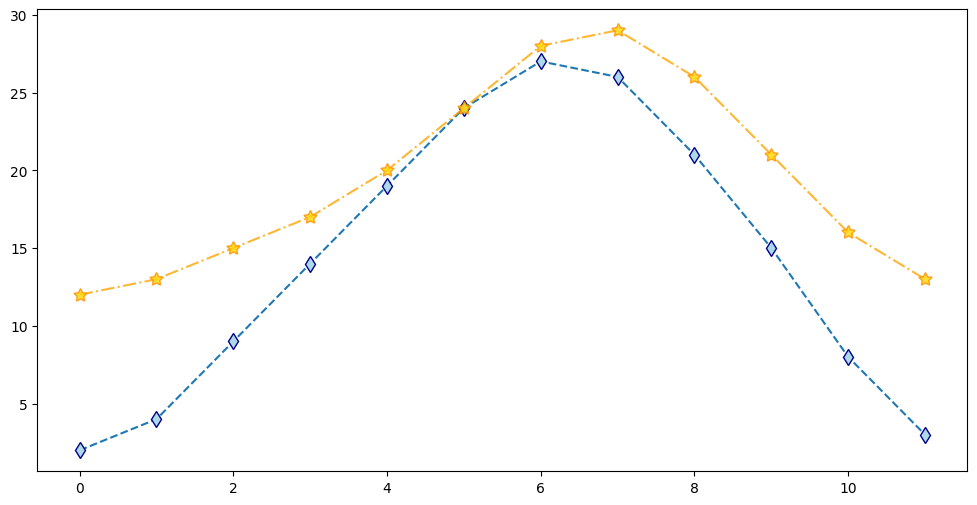

In [9]:
## YOUR CODE HERE
import numpy as np
import matplotlib.ticker as ticker

#figure
fig, ax = plt.subplots(figsize=(12, 6))

#plot
ax.plot(city_a_temps
        , linestyle='--'
        , label='City A'
        , marker='d'
        , markersize=8
        , markerfacecolor='lightblue'
        , markeredgecolor='darkblue'
        )#IK it looks weird, easier to edit 
ax.plot(city_b_temps
        , linestyle='-.'
        , color='orange'
        , alpha=0.8
        , label='City B'
        , marker=(5, 1, 0)
        , markersize=10
        , markerfacecolor='gold'
        , markeredgecolor='darkorange'
        )

# Fill the band between city_a_temps and city_b_temps with transparency and label
ax.fill_between(x, city_a_temps, city_b_temps, color='grey', alpha=0.2, label='difference')

#axis formatting
##ticks
x = np.arange(len(months))
ax.xaxis.set_major_locator(ticker.FixedLocator(x))
ax.xaxis.set_major_formatter(ticker.FixedFormatter(months))

def c_degrees(y, pos):
    return f'{y:.0f}°c'
ax.yaxis.set_major_formatter(ticker.FuncFormatter(c_degrees))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))

#labelling
ax.set_title('Montly Average Temperatures')
#ax.set_ylabel('y')
ax.legend(loc='upper right')
ax.grid(alpha=0.4)
ax.grid(True, which='minor', alpha=0.2)

**5. (25 pts) Create a visualization of the *sun and moon paths across the sky* over a 24-hour period. Your plot should meet the following requirements:**

1. **Sun path. Solid gold line. Use custom sun marker using a tuple (20, 1, 0) to create a 20-pointed star. Size of marker 15, maker color yellow, marker edge color orange. Place Sun markers every 6 data points. Label it as 'Sun'**
2. **Moon path: Solid silver line. Use circle marker with  right fillstyle to create a half-moon effect. Size of marker 12, maker color white, marker edge color gray. Place Moon markers every 3 data points. Label it as 'Moon'**
3. **Horizontal fill for daylight hours. Create a vertical band showing daylight (approximately 6am to 6pm). Use color lightyellow, transparency of 0.3. Label it as 'Daylight'**
4. **Horizontal fill for nighttime. Fill twice for night periods (0-6 and 18-24). Color midnightblue, transparency 0.15. Label it as 'Night' (only label the first one)**
5. **Horizon line. Plot the horizon as a solid brown line. Label it as 'Horizon'**
6. **Add title "Sun and Moon Trajectory (24-Hour Period)", x-label "Hour of Day", y-label "Elevation (degrees)".**
7. **Set x-axis limits to (0, 24) and use `xticks` at every 2 hours with labels like "0:00", "2:00", etc.**
8. **Use figure size of 14, 7**

*Hint. This exercise uses custom tuple markers and `fill_betweenx()`.*

**DATA**

In [ ]:
# Time of day (hours from midnight)
hours = np.linspace(0, 24, 49)

# Sun elevation (degrees above horizon) - rises at 6am, peaks at noon, sets at 6pm
sun_elevation = np.clip(50 * np.sin(np.pi * (hours - 6) / 12), 0, None)#clips negative values to zero

# Moon elevation - rises at 8pm (20:00), peaks at 2am, sets at 8am
moon_raw = 40 * np.sin(np.pi * (hours - 20) / 12)
moon_elevation = np.where((hours >= 20) | (hours <= 8), np.clip(moon_raw, 0, None), 0)

# Horizon line
horizon = np.zeros_like(hours)

# Y values for fill_betweenx
y_fill = np.linspace(0, 55, 100)

In [ ]:
## YOUR CODE HERE
import numpy as np
import matplotlib.ticker as ticker

#figure
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_title('Sun and Moon Trajectory (24 Hour Period)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Elevation (Degrees)')
ax.set_xlim(0,24)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
def clock(x, pos):
    return f'{x:.0f}:00'
ax.xaxis.set_major_formatter(ticker.FuncFormatter(clock))

#plot
ax.plot(hours, moon_elevation
        , linestyle='-'
        , label='Moon'
        , color='silver'
        , marker='o'
        , markevery=3
        , markersize=12
        , markerfacecolor='white'
        , markeredgecolor='grey'
        , fillstyle='right'
        )
ax.plot(hours, sun_elevation
        , linestyle='-'
        , color='orange'
        , alpha=0.8
        , label='Sun'
        , marker=(20, 1, 0)
        , markevery=6
        , markersize=15
        , markerfacecolor='yellow'
        , markeredgecolor='orange'
        )
ax.axhline(y=0, color='brown', label='horizon')

# fill in day and night hours
ax.fill_between(x=hours
    , y1=0 #horizon
    , y2=sun_elevation
    , where=(hours >= 6) & (hours <=18)
    , color='lightyellow'
    , alpha=0.3
    , label='Daylight'
)

ax.fill_between(x=hours
    , y1=0 #horizon
    , y2=moon_elevation
    , where=(hours >= 0) & (hours <=6)
    , color='midnightblue'
    , alpha=0.15
    , label='Nighttime'
)
ax.fill_between(x=hours
    , y1=0 #horizon
    , y2=moon_elevation
    , where=(hours >= 18) & (hours <=24)
    , color='midnightblue'
    , alpha=0.15
)
#I know it doesn't look that pretty but Im a bit rushed now so it is what is 
ax.legend(loc='upper right')
plt.show()